--- First 10 Rows of the Dataset ---
  Student_ID          State       Stream       Main_AI_Tool  Daily_Usage_Time  \
0   STU_1001         Punjab   Management      Perplexity AI               128   
1   STU_1002      Karnataka     Commerce          Grammarly               172   
2   STU_1003      Rajasthan         Arts            ChatGPT                70   
3   STU_1004      Karnataka         Arts  Microsoft Copilot                94   
4   STU_1005     Tamil Nadu  Engineering          Grammarly                86   
5   STU_1006      Rajasthan   Management      Perplexity AI               142   
6   STU_1007      Karnataka     Commerce          Grammarly               178   
7   STU_1008  Uttar Pradesh     Commerce            ChatGPT                59   
8   STU_1009      Karnataka  Engineering          Grammarly                88   
9   STU_1010         Punjab      Medical          Grammarly                75   

       Primary_Purpose        Impact_on_Grades  
0  Learning New Skills

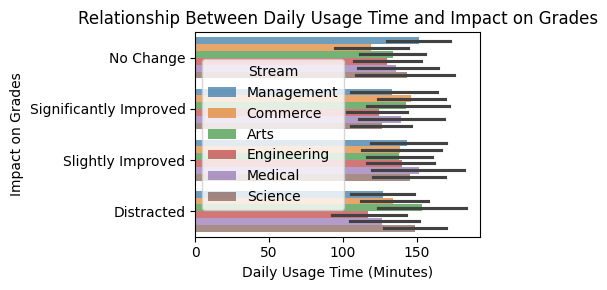

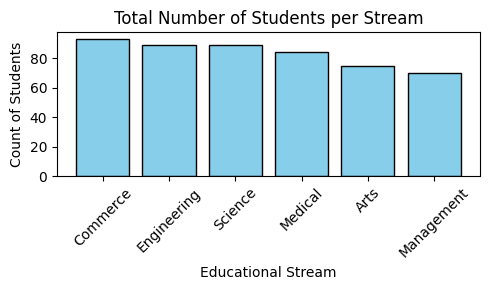

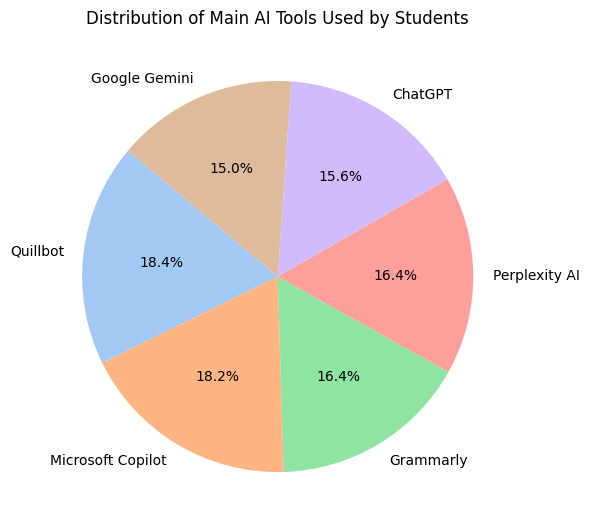

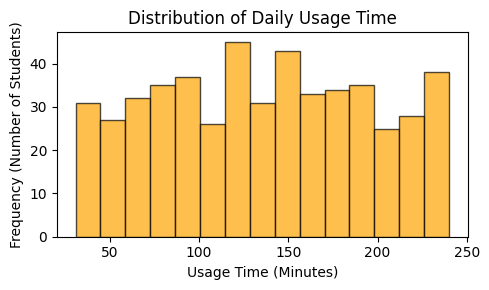

([0, 1, 2, 3],
 [Text(0, 0, 'Significantly Improved'),
  Text(1, 0, 'Slightly Improved'),
  Text(2, 0, 'Distracted'),
  Text(3, 0, 'No Change')])

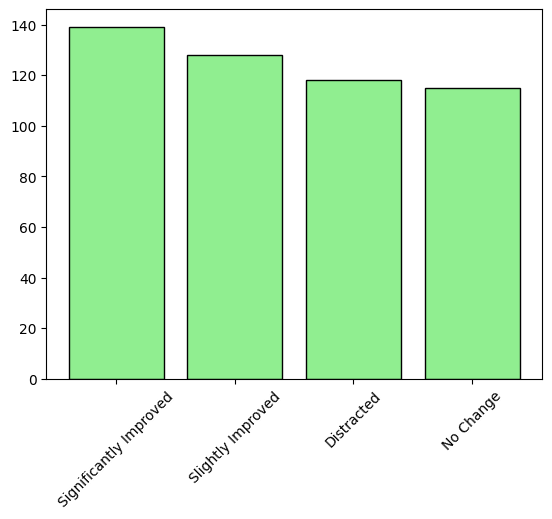

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# 1. Data Loading and Basic Exploration

# Load the dataset
df = pd.read_csv('/content/AI_in_Student_Life_India (1).csv')

print("--- First 10 Rows of the Dataset ---")
print(df.head(10))

print(f"\nDataset Shape (Rows, Columns): {df.shape}")

print("\n--- Dataset Summary Information (info) ---")
df.info()

print("\n--- Descriptive Statistics for 'Daily_Usage_Time' ---")
print(df['Daily_Usage_Time'].describe())

print("\n--- Missing Values Count per Column ---")
print(df.isnull().sum())


# 2. Data Filtering and Grouping Insights


print("\n--- Total Number of Students per Stream ---")
print(df['Stream'].value_counts())

print("\n--- Unique States in the Dataset ---")
print(df['State'].unique())

print("\n--- Unique AI Tools Used by Students ---")
print(df['Main_AI_Tool'].unique())

# Filter data for students who primarily use 'ChatGPT'
chatgpt_users = df[df['Main_AI_Tool'] == 'ChatGPT']

# Calculate the average Daily_Usage_Time for the 'Engineering' stream
avg_time_eng = df[df['Stream'] == 'Engineering']['Daily_Usage_Time'].mean()
print(f"\nAverage Daily Usage Time for Engineering Students: {avg_time_eng:.2f} Minutes")

# Create a new column: Convert Daily_Usage_Time (minutes) to Daily_Usage_Hours
df['Daily_Usage_Hours'] = df['Daily_Usage_Time'] / 60

# Identify top 5 states with the highest average AI usage time
print("\n--- Top 5 States with Highest Average AI Usage Time ---")
top_states = df.groupby('State')['Daily_Usage_Time'].mean().sort_values(ascending=False).head(5)
print(top_states)



# 3. Data Visualization (Data Insights Charts)


# Plot 1: Relationship between Daily Usage Time and Impact on Grades (Scatter Plot)
plt.figure(figsize=(5, 3))
sns.barplot(data=df, x='Daily_Usage_Time', y='Impact_on_Grades', hue='Stream', alpha=0.7)
plt.title('Relationship Between Daily Usage Time and Impact on Grades')
plt.xlabel('Daily Usage Time (Minutes)')
plt.ylabel('Impact on Grades')
plt.tight_layout()
plt.show()



# Plot 2: Number of Students in Each Stream (Bar Chart)
plt.figure(figsize=(5, 3))
stream_counts = df['Stream'].value_counts()
plt.bar(stream_counts.index, stream_counts.values, color='skyblue', edgecolor='black')
plt.title('Total Number of Students per Stream')
plt.xlabel('Educational Stream')
plt.ylabel('Count of Students')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot 3: Distribution of Main AI Tools (Pie Chart)
plt.figure(figsize=(6, 6))
tool_counts = df['Main_AI_Tool'].value_counts()
plt.pie(tool_counts.values, labels=tool_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Distribution of Main AI Tools Used by Students')
plt.tight_layout()
plt.show()

# Plot 4: Distribution of Daily Usage Time (Histogram)
plt.figure(figsize=(5, 3))
plt.hist(df['Daily_Usage_Time'], bins=15, color='orange', edgecolor='black', alpha=0.7)
plt.title('Distribution of Daily Usage Time')
plt.xlabel('Usage Time (Minutes)')
plt.ylabel('Frequency (Number of Students)')
plt.tight_layout()
plt.show()

#Plot 5 : Impact on Grades
grade_counts = df['Impact_on_Grades'].value_counts()
plt.bar(grade_counts.index, grade_counts.values, color='lightgreen', edgecolor='black')
plt.xticks(rotation=45)

